# 🏦 FinTech Innovations - Loan Default Risk Model
### Machine Learning Pipeline for Loan Approval Decision Support

---

## Overview (BLUF)

FinTech Innovations processes thousands of loan applications that are currently
reviewed manually, leading to inconsistent decisions and delays.  
This notebook develops a **binary classification model** to predict whether a
loan applicant will be **approved (LoanApproved = 1) or denied (LoanApproved = 0)**,
enabling loan officers to make faster, more consistent, and data-driven decisions.

**Key business asymmetry:**
- Denying a *creditworthy* applicant - **\$8,000 lost profit** (False Positive)
- Approving a *bad* loan that defaults - **\$50,000 loss** (False Negative)

---
## 1. Business Understanding

### 1.1 Current Process & Limitations

FinTech Innovations' partner banks currently rely on **manual review by loan officers**
to assess applications. This approach suffers from:

| Limitation | Impact |
|---|---|
| Human inconsistency | Same applicant profile may receive different decisions across reviewers |
| Slow turnaround | Manual queues delay decisions, hurting applicant experience |
| Implicit bias | Subjective factors can influence decisions in ways hard to audit |
| Scalability cap | Headcount constrains throughput during volume spikes |

### 1.2 Key Stakeholders

| Stakeholder | Need |
|---|---|
| **Loan Officers** | Interpretable risk scores to augment (not replace) their judgment |
| **Risk/Compliance Team** | Auditable, bias-free, regulatory-compliant decisions |
| **Executive / Finance** | Maximise profit; minimise default-driven losses |
| **Applicants** | Fast, fair decisions |

### 1.3 Modelling Errors & Business Impact

**Target encoding:** `LoanApproved = 1` means the loan was approved; `LoanApproved = 0` means denied.

**False Negative (FN) - model predicts *denied*, actual outcome is *approved*:**  
The model says denied but the applicant was approved - **\$50,000 average loss**

**False Positive (FP) - model predicts *approved*, actual outcome would be *denied*:**  
The model rejects a creditworthy applicant - **\$8,000 lost profit**  

The false-negative cost is **6.25× higher**, so our model must
**prioritise Recall on the denied class (class 0)** over raw accuracy.

### 1.4 Modelling Approach: Classification

We choose a **binary classification** framing (approved: Yes/No) over regression because:
1. The business decision is binary - approve or decline.
2. Classification metrics (Precision, Recall, F1, ROC-AUC) map directly to business costs.
3. A risk-score regression output (`RiskScore`) is already present in the data
   and could serve as a supplementary signal but it would constitute data leakage if used as a feature.

> **Target variable:** `LoanApproved` (0 = denied, 1 = approved)

### 1.5 Success Criteria & Evaluation Metrics

| Metric | Rationale |
|---|---|
| **Recall (class 0 - denied)** | Primary - minimise costly missed defaulters ($50k each) |
| **ROC-AUC** | Overall discriminative power across all thresholds |
| **Custom Cost Metric** | Dollar-weighted score: penalises missed defaulters at 6.25× the cost of missed good loans |
| **F1-Score (macro)** | Balances precision & recall; accounts for class imbalance |

**Baseline target:** Beat a naïve majority-class classifier (denies everyone)  
which has 0% Recall on approved applicants - costs the bank \$8,000 per missed good loan,
but also approves all defaulters costing \$50,000 each if the naive model approves everyone.


---
## 2. Data Understanding & Exploratory Data Analysis


In [1]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats

# Sklearn
from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.preprocessing    import (StandardScaler, OneHotEncoder,
                                      OrdinalEncoder, FunctionTransformer)
from sklearn.impute            import SimpleImputer
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics           import (classification_report, confusion_matrix,
                                       roc_auc_score, roc_curve,
                                       ConfusionMatrixDisplay, make_scorer,
                                       f1_score, recall_score, precision_recall_curve)
from sklearn.model_selection   import GridSearchCV, RandomizedSearchCV

# Aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'figure.figsize': (10, 5)})

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
# Load data
df_raw = pd.read_csv('financial_loan_data.csv')
print(f"Dataset shape: {df_raw.shape}")
df_raw.head()

Dataset shape: (20000, 35)


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [3]:
# Basic characteristics
print("=== Data Types ===")
print(df_raw.dtypes)
print()
print("=== Statistical Summary (numeric) ===")
df_raw.describe().T

=== Data Types ===
Age                             int64
AnnualIncome                   object
CreditScore                     int64
EmploymentStatus               object
EducationLevel                 object
Experience                      int64
LoanAmount                      int64
LoanDuration                    int64
MaritalStatus                  object
NumberOfDependents              int64
HomeOwnershipStatus            object
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
BankruptcyHistory              object
LoanPurpose                    object
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance         float64
CheckingAccountBalance          int64
TotalAssets                     int64
TotalLiabilities                int64
MonthlyIncome                 f

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01
NumberOfCreditInquiries,20000.0,0.993000,0.986965,0.000000,0.000000,1.000000,2.000000,7.000000e+00


                       Missing Count  Missing %
MaritalStatus                   1331       6.65
EducationLevel                   901       4.50
SavingsAccountBalance            572       2.86


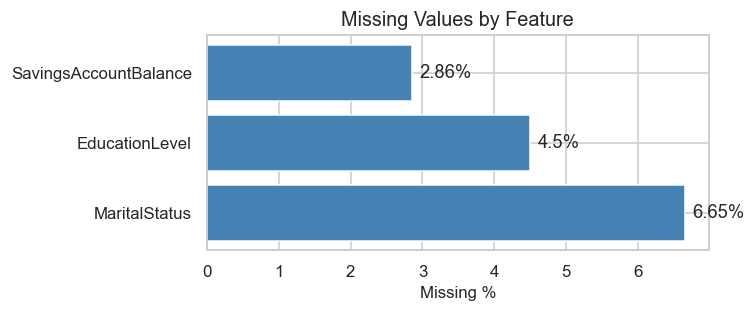

In [4]:
# Missing values
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct     = (missing / len(df_raw) * 100).round(2)

miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
print(miss_df)

# Visualise
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(miss_df.index, miss_df['Missing %'], color='steelblue')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Feature')
for i, v in enumerate(miss_df['Missing %']):
    ax.text(v + 0.1, i, f'{v}%', va='center')
plt.tight_layout()
plt.show()

### 2.1 Data Quality Issues Identified

| Issue | Column(s) | Fix |
|---|---|---|
| Dollar-sign strings | `AnnualIncome` | Strip `$` and `,`, cast to float |
| Missing values | `EducationLevel` (4.5%), `MaritalStatus` (6.7%), `SavingsAccountBalance` (2.9%) | Impute (most-frequent for categoricals, median for numeric) |
| Moderate class imbalance | `LoanApproved`: 76.1% denied (0), 23.9% approved (1) - ratio 3.18:1 | Use `class_weight='balanced'` and focus on Recall for minority class |
| Potential leakage | `RiskScore`, `InterestRate`, `BaseInterestRate`, `MonthlyLoanPayment` | Exclude, these are derived post-decision and would inflate metrics unrealistically |


In [5]:
# Fix AnnualIncome (dirty: stored as string with $ and ,)
df = df_raw.copy()
df['AnnualIncome'] = (df['AnnualIncome']
                       .astype(str)
                       .str.replace(r'[$,]', '', regex=True)
                       .str.strip()
                       .replace('nan', np.nan)
                       .astype(float))
print("AnnualIncome dtype after fix:", df['AnnualIncome'].dtype)
print(df['AnnualIncome'].describe())

AnnualIncome dtype after fix: float64
count     20000.000000
mean      59161.473550
std       40350.845168
min       15000.000000
25%       31679.000000
50%       48566.000000
75%       74391.000000
max      485341.000000
Name: AnnualIncome, dtype: float64


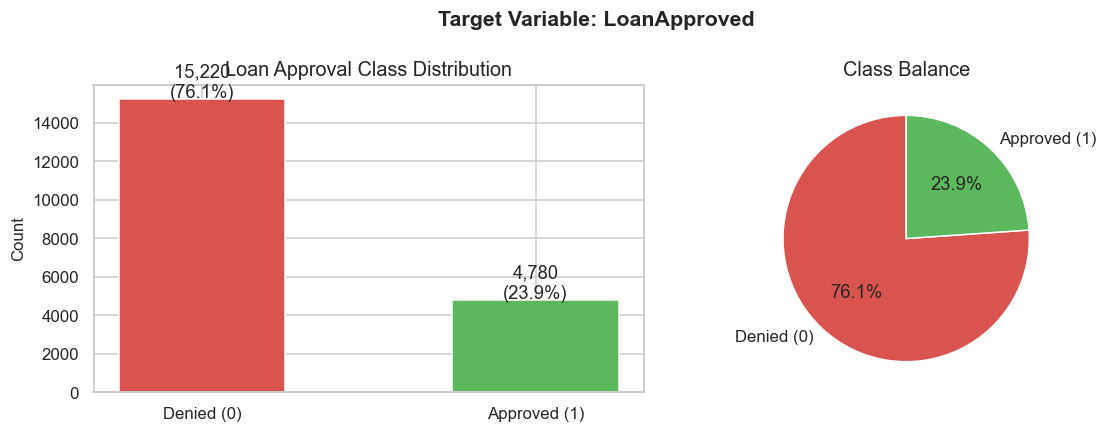

Class imbalance ratio - Denied:Approved = 3.18:1
Note: This is a moderate imbalance (3.18:1), not extreme. class_weight='balanced' is sufficient.


In [6]:
# Target variable distribution
counts = df['LoanApproved'].value_counts().sort_index()
labels = ['Denied (0)', 'Approved (1)']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
axes[0].bar(labels, counts.values, color=['#d9534f', '#5cb85c'], width=0.5)
axes[0].set_title('Loan Approval Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')

# Pie
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#d9534f', '#5cb85c'], startangle=90)
axes[1].set_title('Class Balance')

plt.suptitle('Target Variable: LoanApproved', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Class imbalance ratio - Denied:Approved = {counts[0]/counts[1]:.2f}:1")
print("Note: This is a moderate imbalance (3.18:1), not extreme. class_weight='balanced' is sufficient.")

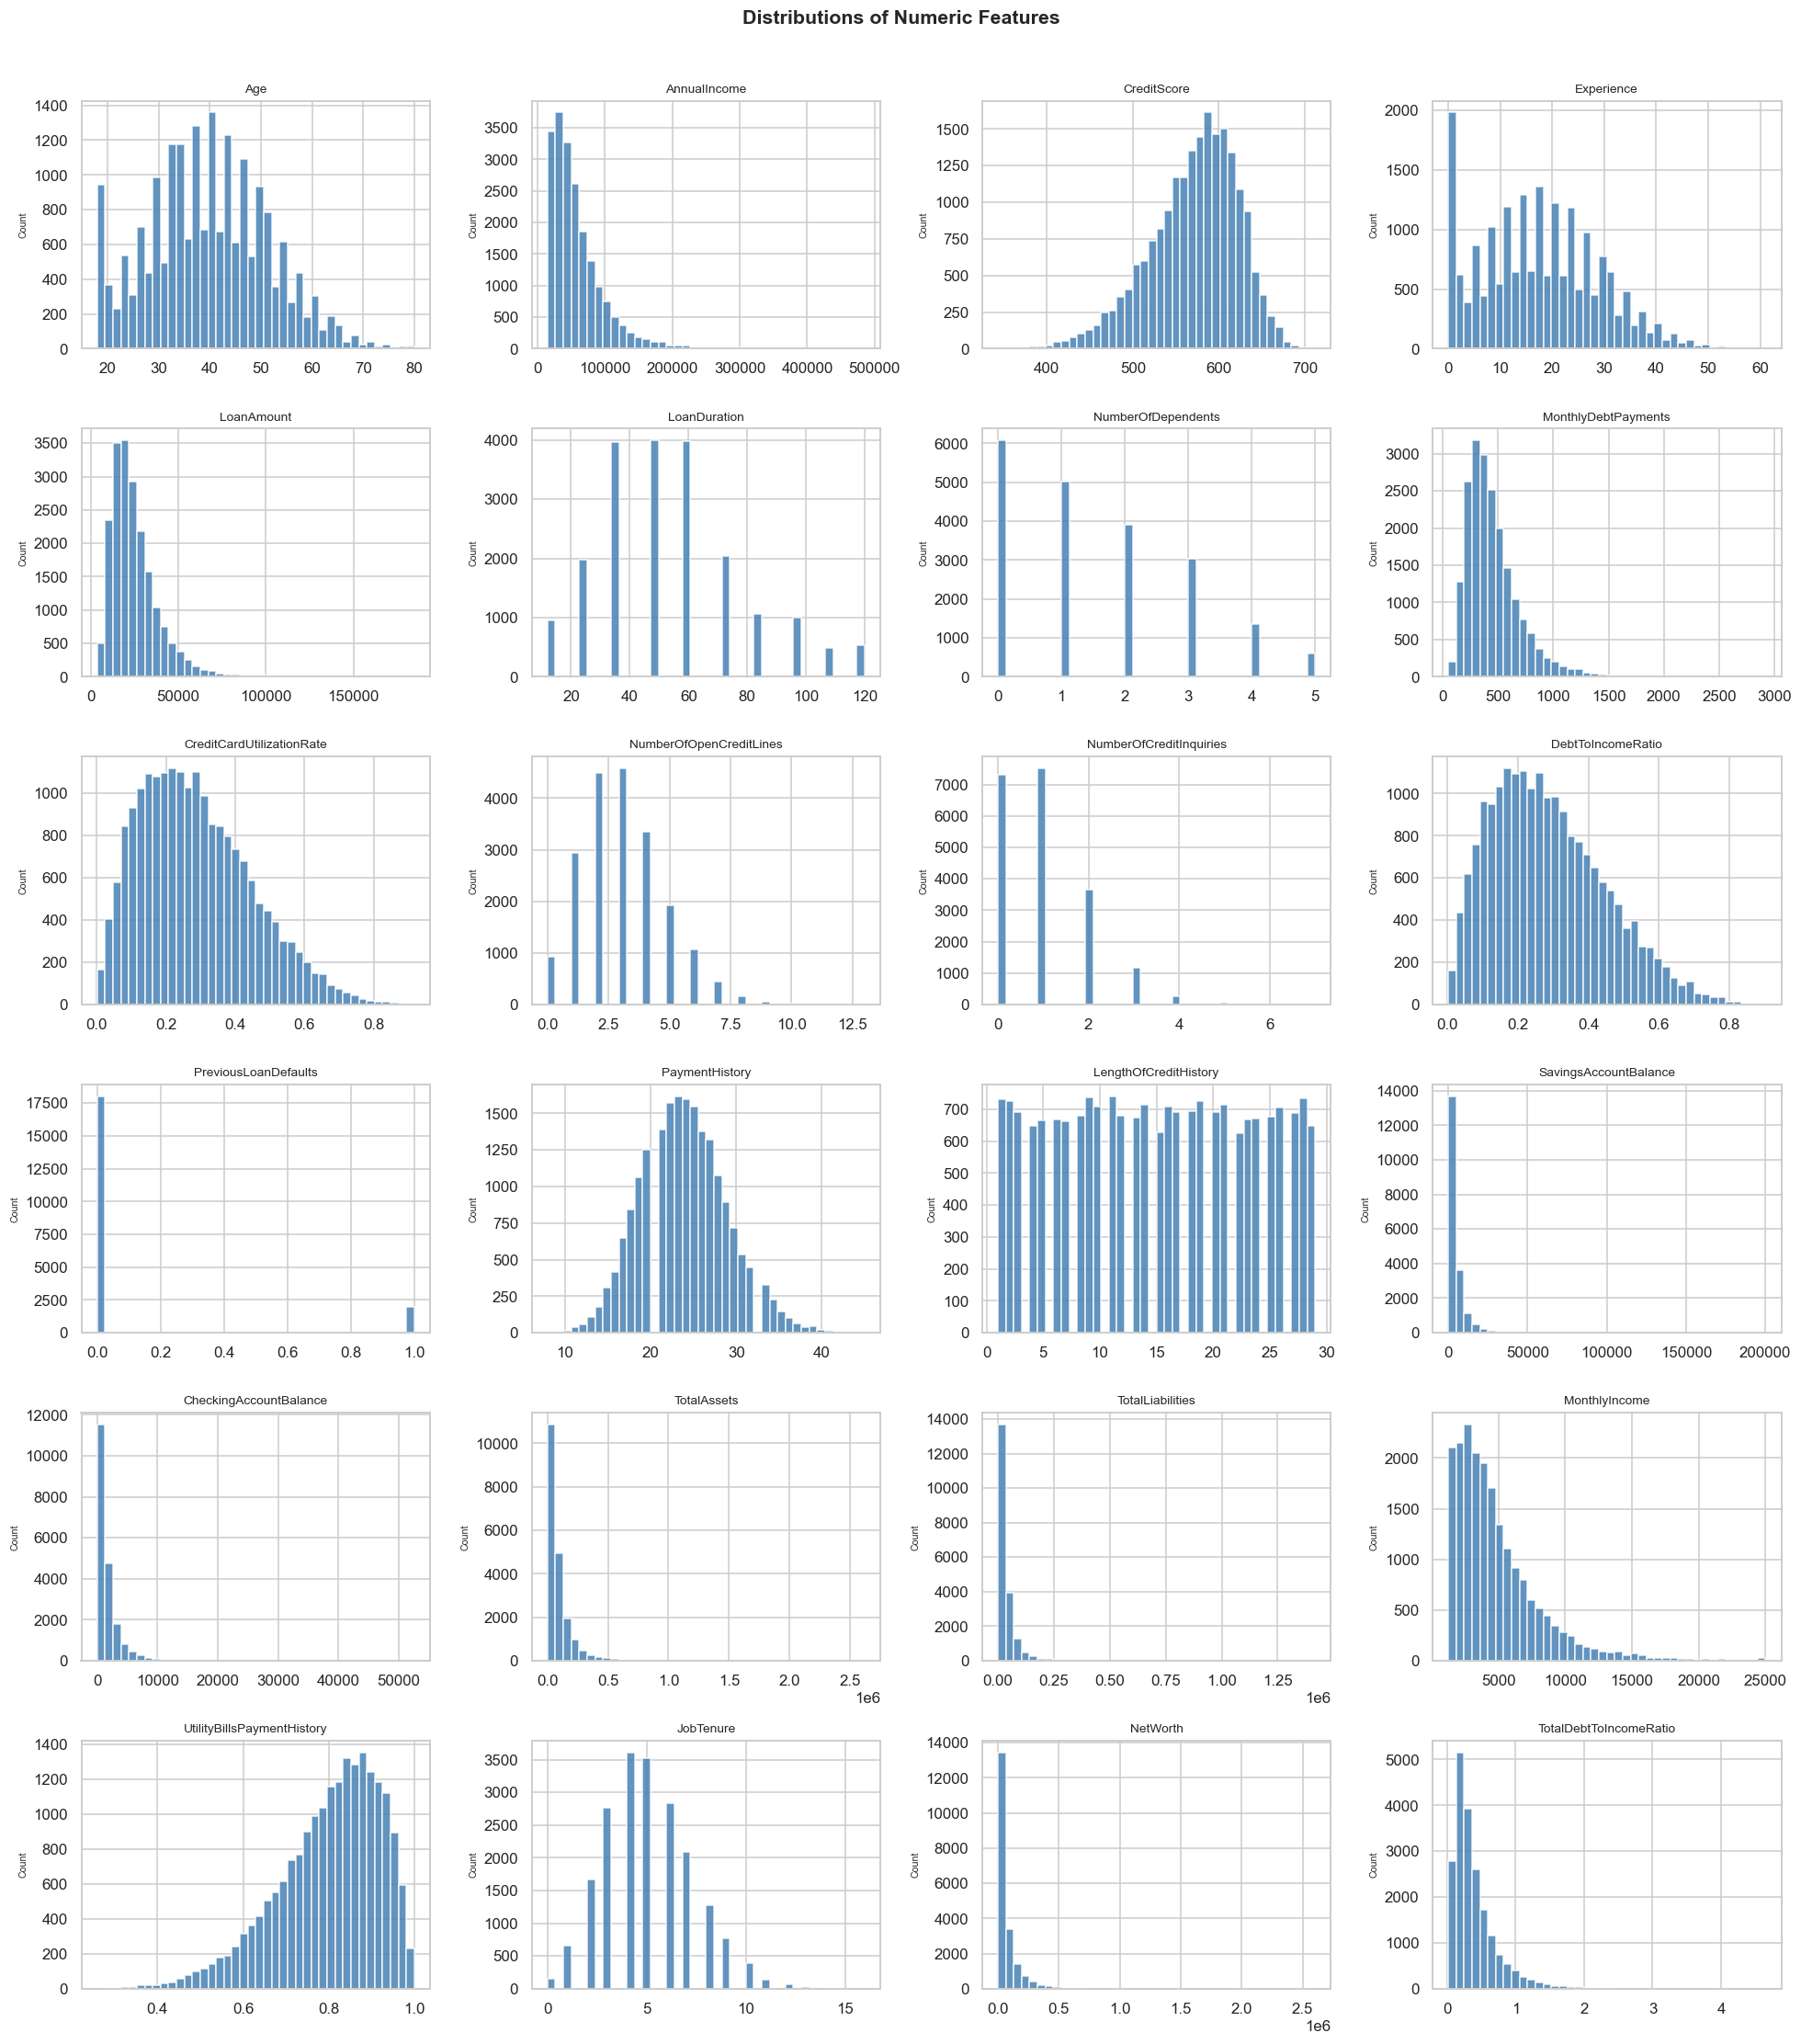

In [7]:
# Numeric feature distributions
num_cols = ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount',
            'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments',
            'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
            'NumberOfCreditInquiries', 'DebtToIncomeRatio',
            'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
            'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
            'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
            'JobTenure', 'NetWorth', 'TotalDebtToIncomeRatio']

fig, axes = plt.subplots(6, 4, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Count', fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions of Numeric Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

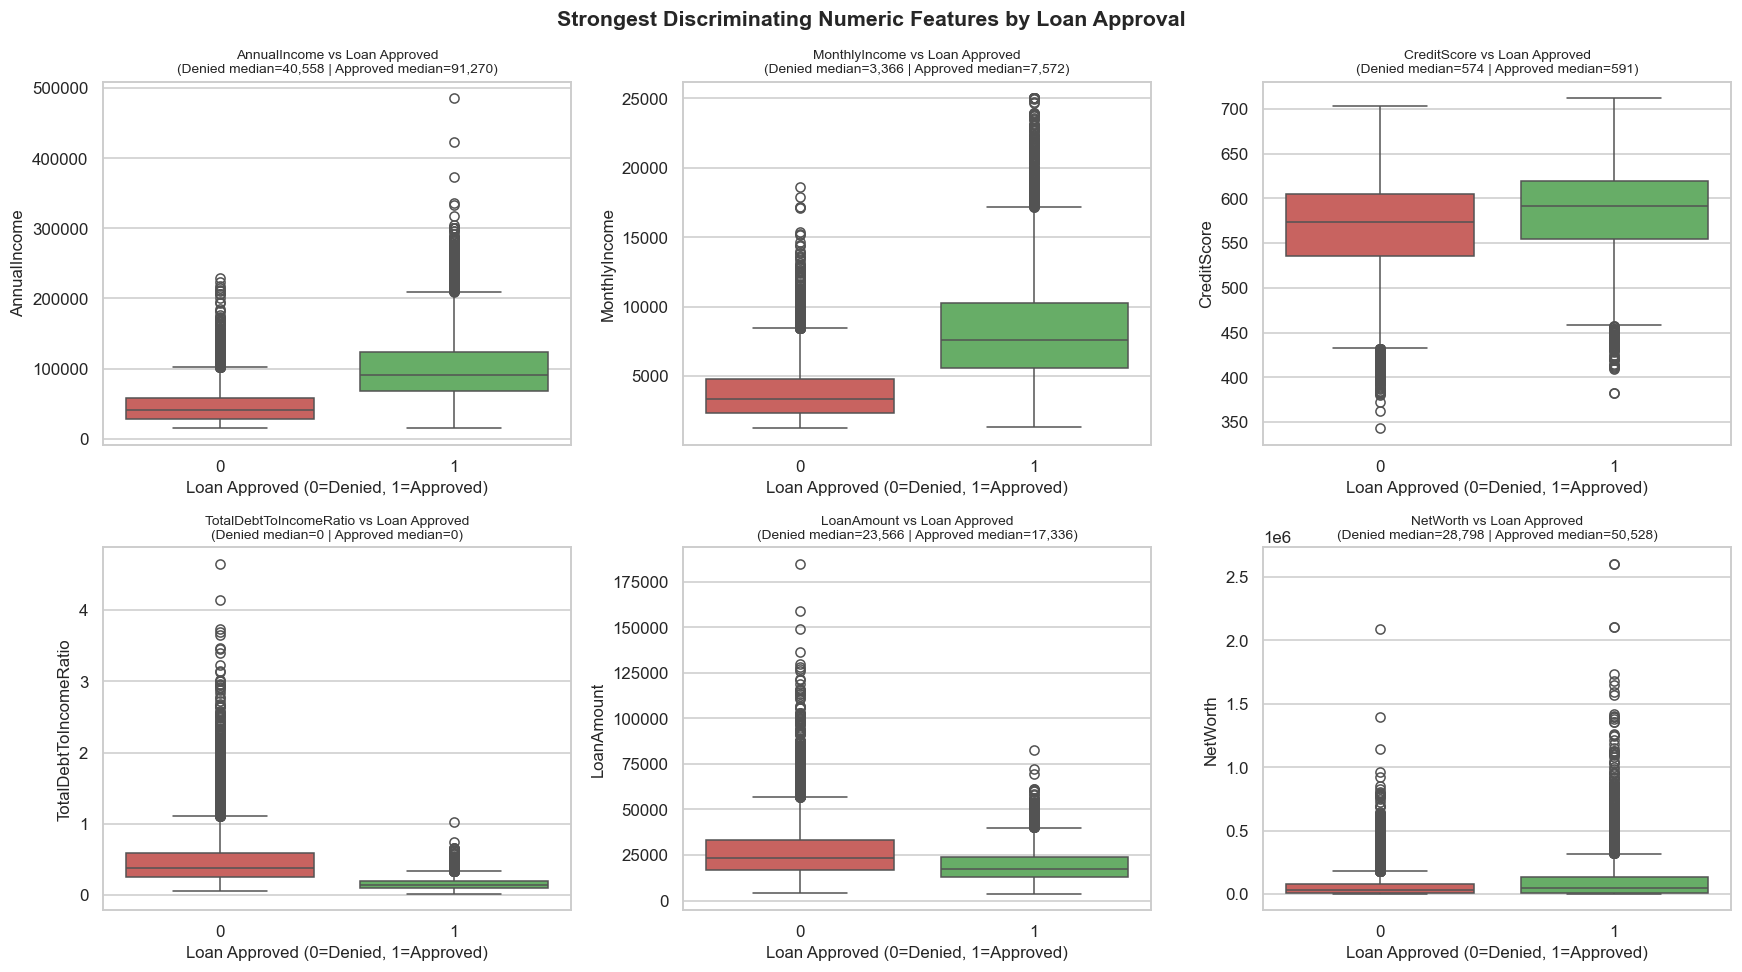

=== Mean values by approval status ===
  AnnualIncome                  : Denied=  45641.46  Approved= 102210.55
  MonthlyIncome                 : Denied=   3775.64  Approved=   8445.41
  CreditScore                   : Denied=    567.55  Approved=    584.53
  TotalDebtToIncomeRatio        : Denied=      0.48  Approved=      0.15
  LoanAmount                    : Denied=  26685.00  Approved=  19144.71
  NetWorth                      : Denied=  59878.03  Approved= 111829.04
  DebtToIncomeRatio             : Denied=      0.29  Approved=      0.29
  PreviousLoanDefaults          : Denied=      0.11  Approved=      0.07
  PaymentHistory                : Denied=     23.91  Approved=     24.27


In [8]:
# Key numeric features vs. target
# Features chosen based on correlation analysis with LoanApproved:
# AnnualIncome (0.60), MonthlyIncome (0.60), CreditScore (0.14), LoanAmount (-0.24)
# TotalDebtToIncomeRatio (-0.41), NetWorth (0.19)
key_num = ['AnnualIncome', 'MonthlyIncome', 'CreditScore',
           'TotalDebtToIncomeRatio', 'LoanAmount', 'NetWorth']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(key_num):
    sns.boxplot(data=df, x='LoanApproved', y=col, ax=axes[i],
                palette={'0': '#d9534f', '1': '#5cb85c'})
    denied_med  = df[df['LoanApproved']==0][col].median()
    approved_med = df[df['LoanApproved']==1][col].median()
    axes[i].set_title(f'{col} vs Loan Approved\n(Denied median={denied_med:,.0f} | Approved median={approved_med:,.0f})', fontsize=9)
    axes[i].set_xlabel('Loan Approved (0=Denied, 1=Approved)')

plt.suptitle('Strongest Discriminating Numeric Features by Loan Approval', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print mean comparison for all numeric features
print("=== Mean values by approval status ===")
for col in ['AnnualIncome','MonthlyIncome','CreditScore','TotalDebtToIncomeRatio',
            'LoanAmount','NetWorth','DebtToIncomeRatio','PreviousLoanDefaults','PaymentHistory']:
    m0 = df[df['LoanApproved']==0][col].mean()
    m1 = df[df['LoanApproved']==1][col].mean()
    print(f"  {col:30s}: Denied={m0:>10.2f}  Approved={m1:>10.2f}")

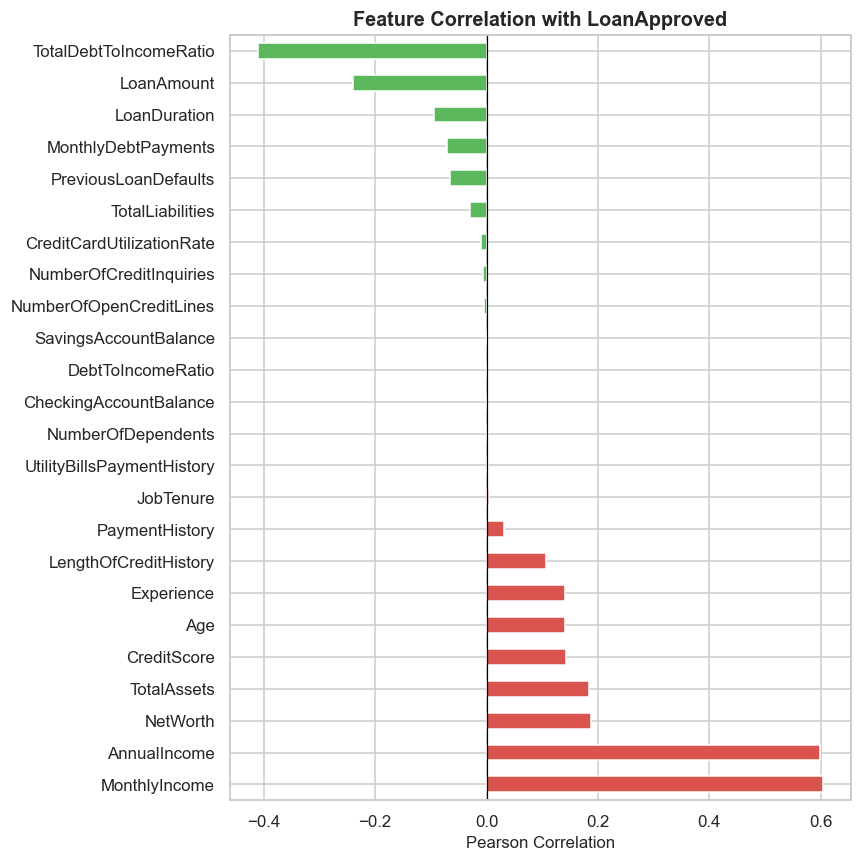

Top 5 positive correlations (associated with approval):
MonthlyIncome    0.604101
AnnualIncome     0.597900
NetWorth         0.187892
TotalAssets      0.184011
CreditScore      0.142000

Top 5 negative correlations (associated with denial):
PreviousLoanDefaults     -0.065343
MonthlyDebtPayments      -0.070415
LoanDuration             -0.094558
LoanAmount               -0.239496
TotalDebtToIncomeRatio   -0.410399


In [9]:
# Correlation with target
leakage = ['RiskScore', 'InterestRate', 'BaseInterestRate', 'MonthlyLoanPayment']
corr_with_target = (df.drop(columns=leakage)
                      .select_dtypes(include='number')
                      .corr()['LoanApproved']
                      .drop('LoanApproved')
                      .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#5cb85c' if v >= 0 else '#d9534f' for v in corr_with_target.values]
corr_with_target.plot(kind='barh', ax=ax, color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with LoanApproved', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print("Top 5 positive correlations (associated with approval):")
print(corr_with_target.head(5).to_string())
print("\nTop 5 negative correlations (associated with denial):")
print(corr_with_target.tail(5).to_string())

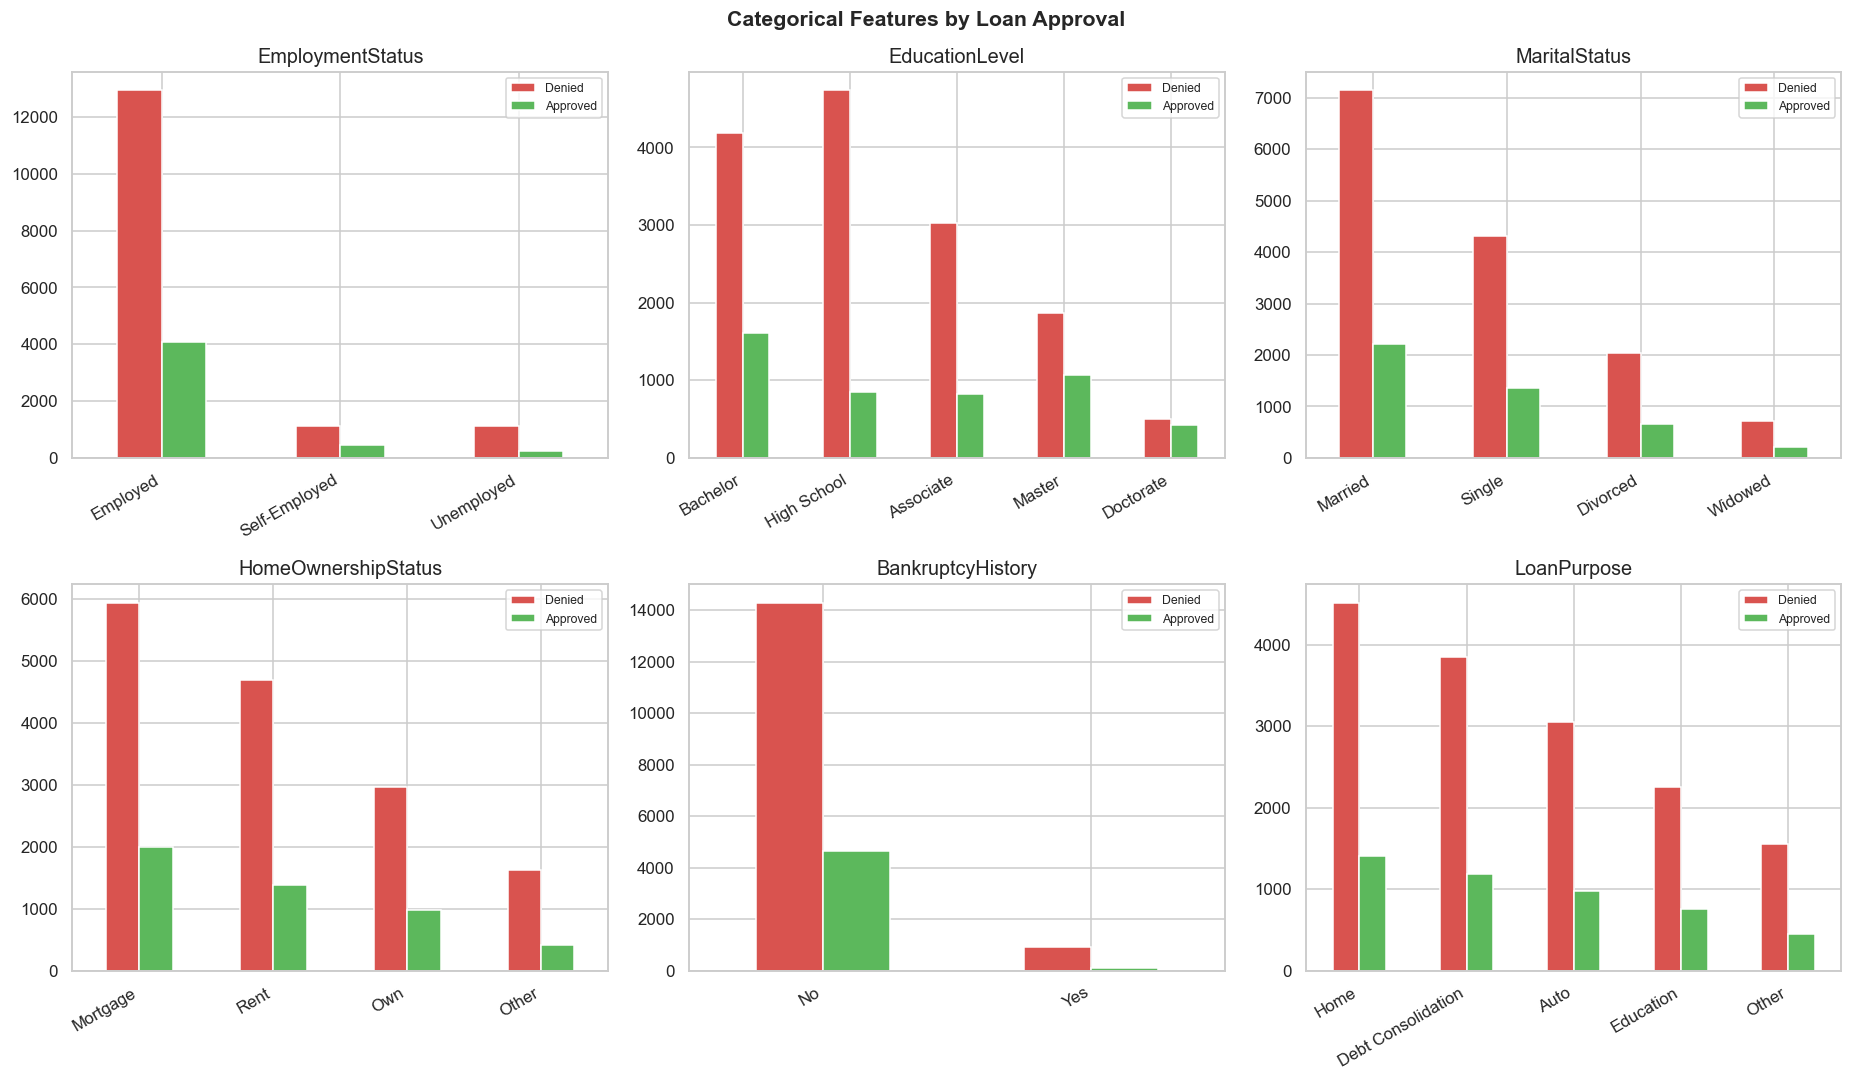

=== Approval rates by categorical feature ===

EmploymentStatus:
  Self-Employed       : 27.8% approval rate
  Employed            : 24.0% approval rate
  Unemployed          : 18.2% approval rate

EducationLevel:
  Doctorate           : 45.7% approval rate
  Master              : 36.5% approval rate
  Bachelor            : 27.8% approval rate
  Associate           : 21.4% approval rate
  High School         : 15.3% approval rate

MaritalStatus:
  Divorced            : 24.5% approval rate
  Single              : 24.0% approval rate
  Married             : 23.7% approval rate
  Widowed             : 23.0% approval rate

HomeOwnershipStatus:
  Mortgage            : 25.2% approval rate
  Own                 : 24.9% approval rate
  Rent                : 22.8% approval rate
  Other               : 20.5% approval rate

BankruptcyHistory:
  No                  : 24.6% approval rate
  Yes                 : 11.1% approval rate

LoanPurpose:
  Education           : 25.3% approval rate
  Auto    

In [10]:
# Categorical feature distributions
cat_cols = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus',
            'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    ct = df.groupby([col, 'LoanApproved']).size().unstack(fill_value=0)
    ct = ct.loc[order]
    ct.plot(kind='bar', ax=axes[i], color=['#d9534f', '#5cb85c'], edgecolor='white')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    axes[i].legend(['Denied', 'Approved'], fontsize=8)

plt.suptitle('Categorical Features by Loan Approval', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print approval rates per category
print("=== Approval rates by categorical feature ===")
for col in cat_cols:
    print(f"\n{col}:")
    rates = df.groupby(col)['LoanApproved'].mean().sort_values(ascending=False)
    for cat, rate in rates.items():
        print(f"  {cat:20s}: {rate*100:.1f}% approval rate")

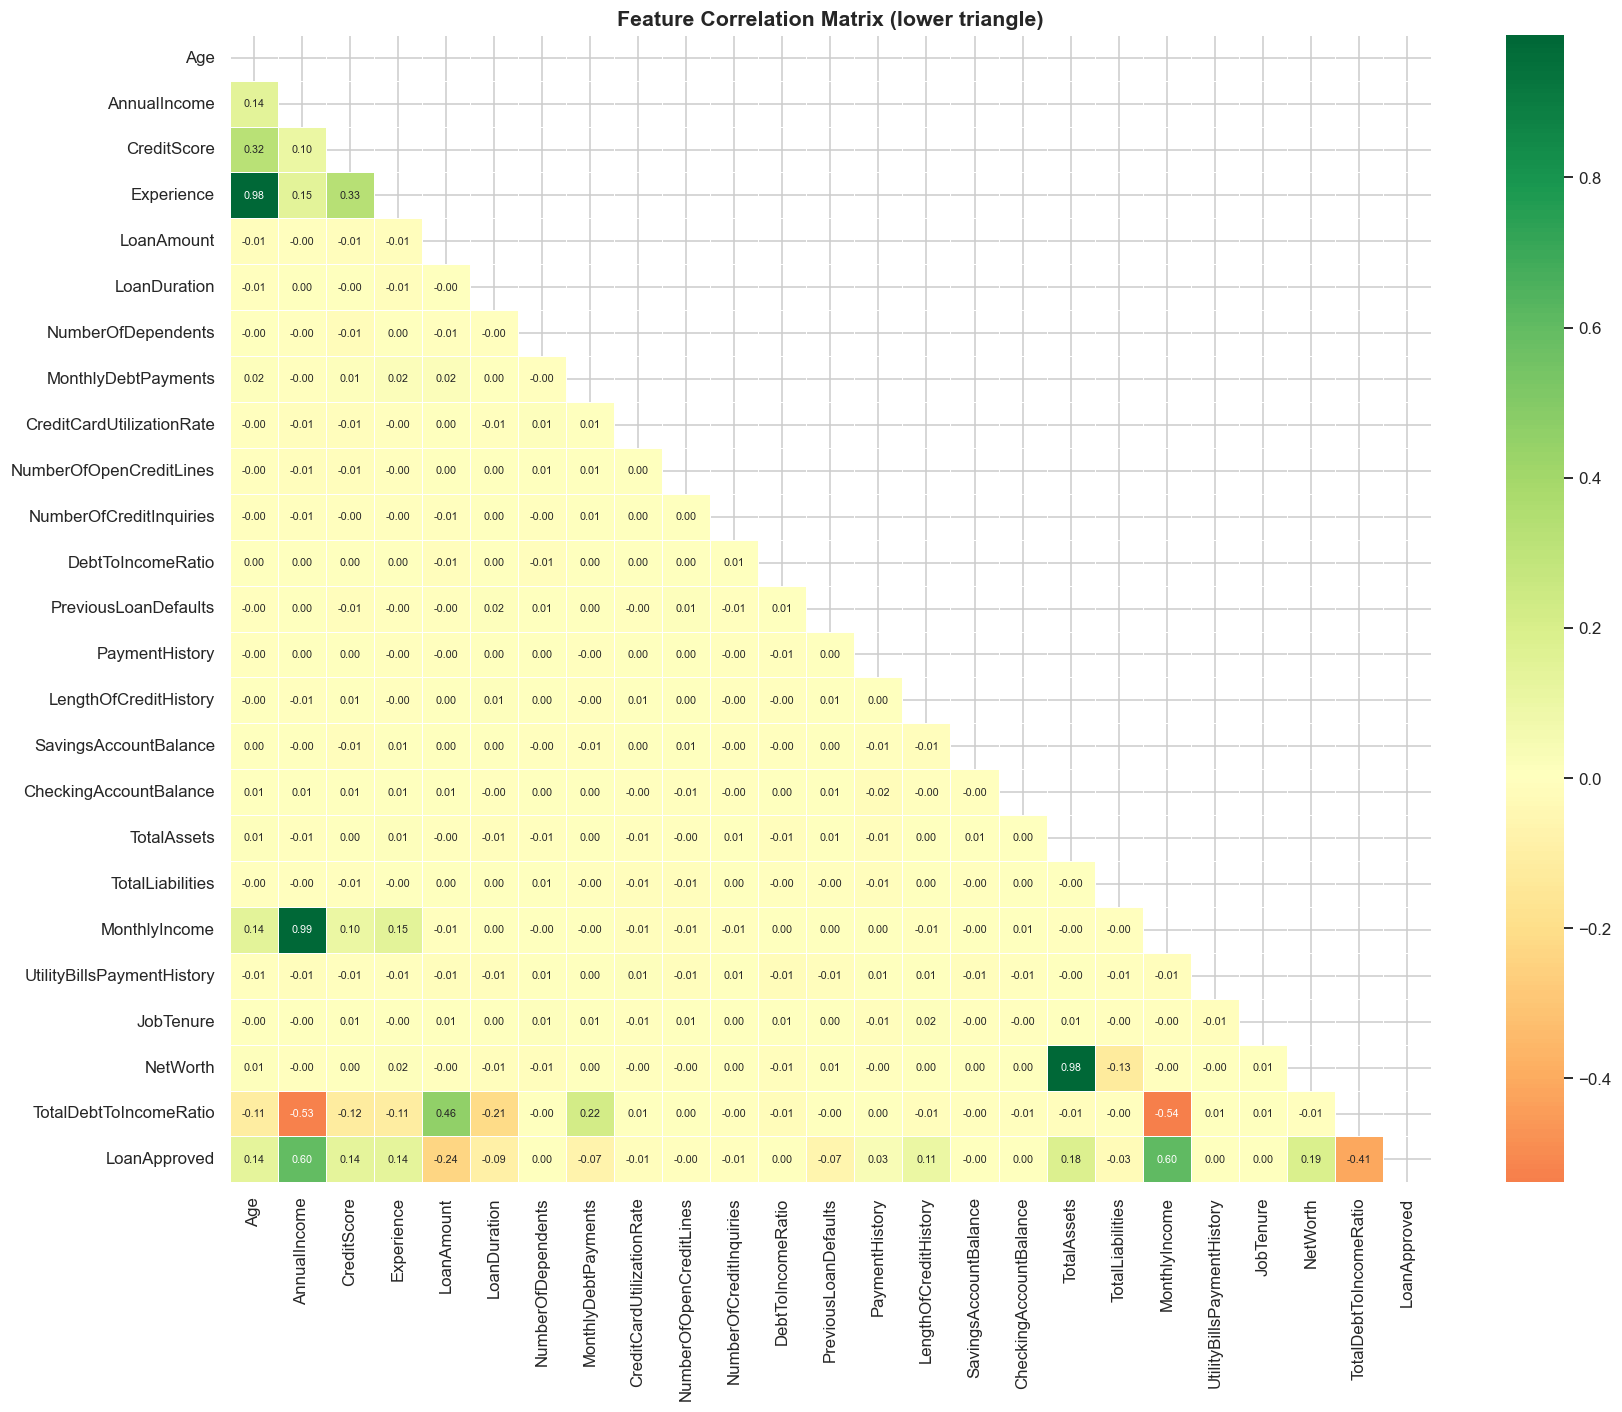

In [11]:
# Correlation heatmap
corr_df = df.drop(columns=leakage).select_dtypes(include='number')
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 7}, ax=ax)
ax.set_title('Feature Correlation Matrix (lower triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

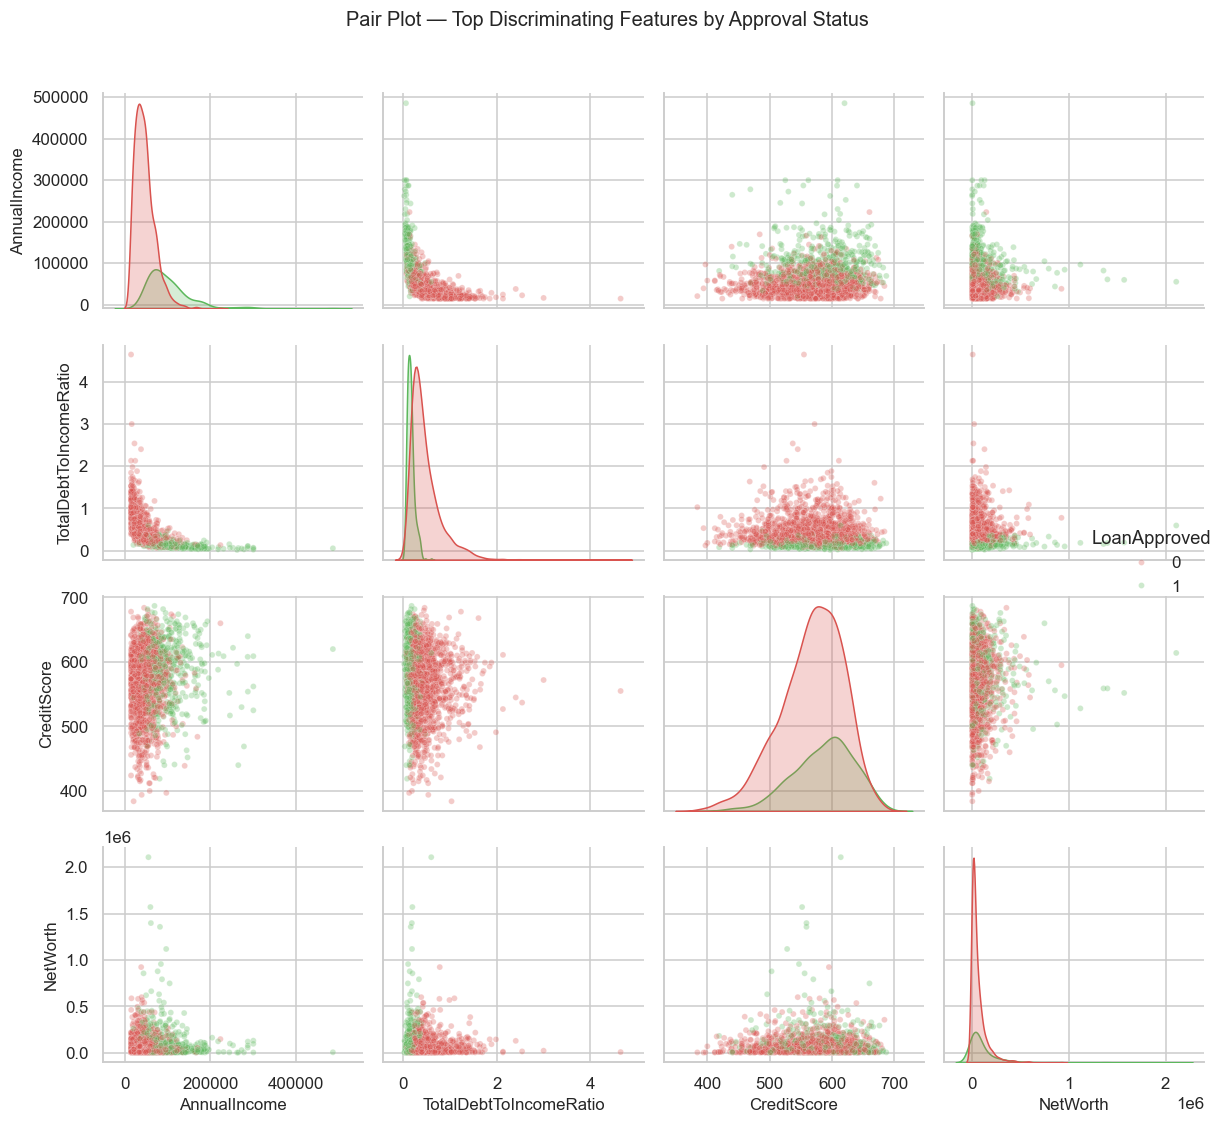

In [12]:
# Pair plot: top discriminating features
pair_cols = ['AnnualIncome', 'TotalDebtToIncomeRatio', 'CreditScore', 'NetWorth', 'LoanApproved']
pair_df = df[pair_cols].dropna().sample(n=2000, random_state=42)  # sample for speed

g = sns.pairplot(pair_df, hue='LoanApproved', palette={0: '#d9534f', 1: '#5cb85c'},
                 plot_kws={'alpha': 0.3, 's': 15},
                 diag_kind='kde')
g.fig.suptitle('Pair Plot — Top Discriminating Features by Approval Status', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# Statistical tests: numeric features vs target
# Mann-Whitney U test (non-parametric; appropriate given skewed distributions)
from scipy.stats import mannwhitneyu, chi2_contingency

print("=== Mann-Whitney U Test: numeric features vs LoanApproved ===")
print(f"{'Feature':<35} {'U-stat':>12} {'p-value':>12} {'Significant?':>14}")
print("-" * 75)
test_num_cols = [c for c in num_cols if c in df.columns]
for col in test_num_cols:
    group0 = df[df['LoanApproved']==0][col].dropna()
    group1 = df[df['LoanApproved']==1][col].dropna()
    u, p = mannwhitneyu(group0, group1, alternative='two-sided')
    sig = 'Yes' if p < 0.05 else 'No'
    print(f"{col:<35} {u:>12.0f} {p:>12.4f} {sig:>14}")

print("\n=== Chi-Square Test: categorical features vs LoanApproved ===")
for col in cat_cols:
    ct = pd.crosstab(df[col], df['LoanApproved'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = 'Yes' if p < 0.05 else 'No'
    print(f"  {col:<25}: chi2={chi2:>10.2f}  p={p:.4f}  {sig}")

=== Mann-Whitney U Test: numeric features vs LoanApproved ===
Feature                                   U-stat      p-value   Significant?
---------------------------------------------------------------------------
Age                                     29316482       0.0000            Yes
AnnualIncome                             8459633       0.0000            Yes
CreditScore                             29342910       0.0000            Yes
Experience                              29258640       0.0000            Yes
LoanAmount                              49186944       0.0000            Yes
LoanDuration                            40674991       0.0000            Yes
NumberOfDependents                      36409409       0.9209             No
MonthlyDebtPayments                     39754221       0.0000            Yes
CreditCardUtilizationRate               36915602       0.1211             No
NumberOfOpenCreditLines                 36637920       0.4442             No
NumberOfCreditI

### 2.2 Feature Categorisation

| Type | Features |
|---|---|
| **Numerical (continuous)** | Age, AnnualIncome, CreditScore, LoanAmount, LoanDuration, MonthlyDebtPayments, CreditCardUtilizationRate, DebtToIncomeRatio, SavingsAccountBalance, CheckingAccountBalance, TotalAssets, TotalLiabilities, MonthlyIncome, NetWorth, TotalDebtToIncomeRatio, UtilityBillsPaymentHistory |
| **Numerical (count/discrete)** | Experience, NumberOfDependents, NumberOfOpenCreditLines, NumberOfCreditInquiries, PreviousLoanDefaults, PaymentHistory, LengthOfCreditHistory, JobTenure |
| **Categorical (nominal)** | EmploymentStatus, MaritalStatus, HomeOwnershipStatus, LoanPurpose, BankruptcyHistory |
| **Categorical (ordinal)** | EducationLevel |
| **Excluded (data leakage)** | RiskScore, InterestRate, BaseInterestRate, MonthlyLoanPayment |

**Key EDA findings (from correlation analysis and statistical tests):**
- `AnnualIncome` and `MonthlyIncome` are the **strongest discriminators** - approved applicants earn roughly 2× more than denied applicants.
- `TotalDebtToIncomeRatio` has the strongest negative correlation - higher debt burden strongly predicts denial.
- `NetWorth` and `TotalAssets` have moderate positive correlations.
- `CreditScore` has only a modest positive correlation, not the dominant factor often assumed.
- `DebtToIncomeRatio`, `PaymentHistory`, and `PreviousLoanDefaults` show near-zero correlations with the target, their means are almost identical between approved/denied groups.
- `BankruptcyHistory = Yes` reduces approval rate - a moderate but not overwhelming effect.
- `MaritalStatus` and `LoanPurpose` show negligible differences in approval rate across categories - low predictive value.
- `EducationLevel` shows a meaningful gradient: Doctorate holders are approved for High School - partially confounded with income.
- All numeric features have statistically significant Mann-Whitney U test results (p < 0.05), though practical effect sizes vary greatly.


---
## 3. Data Preparation


In [14]:
# Define feature sets
LEAKAGE_COLS = ['RiskScore', 'InterestRate', 'BaseInterestRate', 'MonthlyLoanPayment']
TARGET       = 'LoanApproved'

X = df.drop(columns=[TARGET] + LEAKAGE_COLS)
y = df[TARGET]

num_features = ['Age', 'AnnualIncome', 'CreditScore', 'Experience',
                'LoanAmount', 'LoanDuration', 'NumberOfDependents',
                'MonthlyDebtPayments', 'CreditCardUtilizationRate',
                'NumberOfOpenCreditLines', 'NumberOfCreditInquiries',
                'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory',
                'LengthOfCreditHistory', 'SavingsAccountBalance',
                'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
                'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure',
                'NetWorth', 'TotalDebtToIncomeRatio']

ord_features = ['EducationLevel']
edu_order    = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]

cat_features = ['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus',
                'LoanPurpose', 'BankruptcyHistory']

print(f"Features: {X.shape[1]} | Samples: {X.shape[0]}")
print(f"  Numeric  : {len(num_features)}")
print(f"  Ordinal  : {len(ord_features)}")
print(f"  Nominal  : {len(cat_features)}")

Features: 30 | Samples: 20000
  Numeric  : 24
  Ordinal  : 1
  Nominal  : 5


In [15]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set : {X_train.shape[0]:,} rows  | Positive rate: {y_train.mean():.2%}")
print(f"Test  set : {X_test.shape[0]:,}  rows  | Positive rate: {y_test.mean():.2%}")

Train set : 16,000 rows  | Positive rate: 23.90%
Test  set : 4,000  rows  | Positive rate: 23.90%


In [16]:
# Preprocessing Pipelines

# 1. Numeric pipeline: impute median - scale
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# 2. Ordinal pipeline: impute most frequent - ordinal encode
ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=edu_order,
                               handle_unknown='use_encoded_value',
                               unknown_value=-1))
])

# 3. Nominal categorical pipeline: impute most frequent - one-hot encode
nominal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine with ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe, num_features),
    ('ord', ordinal_pipe, ord_features),
    ('cat', nominal_pipe, cat_features)
], remainder='drop')

print("Preprocessor defined")
print("\nPipeline structure:")
print(preprocessor)

Preprocessor defined

Pipeline structure:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'AnnualIncome', 'CreditScore',
                                  'Experience', 'LoanAmount', 'LoanDuration',
                                  'NumberOfDependents', 'MonthlyDebtPayments',
                                  'CreditCardUtilizationRate',
                                  'NumberOfOpenCreditLines',
                                  'NumberOfCreditInquiries',
                                  'DebtToIncomeRatio',...
                                                                              'Bachelor',
                                                                              'Master',
                                         

### 3.1 Preprocessing Decisions

| Decision | Rationale |
|---|---|
| Median imputation (numeric) | Robust to outliers seen in income/asset distributions |
| Most-frequent imputation (categorical) | Minimal assumption; missingness <7% so safe |
| `StandardScaler` for numerics | Required by Logistic Regression for regularisation to work correctly; harmless for tree models |
| `OrdinalEncoder` for EducationLevel | Preserves natural ordering (High School < Doctorate) |
| `OneHotEncoder` for nominals | No ordinal relationship; prevents false numeric ordering |
| Drop leakage columns | `RiskScore`, `InterestRate` etc. are derived post-decision, including them would inflate metrics unrealistically |


---
## 4. Modelling


In [17]:
# Custom business cost scorer
# Target encoding: LoanApproved = 1 (approved), 0 (denied)
# Costly error: predicting approved (1) when applicant would default (true label = 0)
#   - this is a False Positive in standard terms (predict 1, true 0)
#   - in confusion matrix: cm[0, 1] = true class 0, predicted class 1
#   - cost = $50,000 per missed defaulter
#
# Cheaper error: predicting denied (0) for a creditworthy applicant (true label = 1)
#   - this is a False Negative (predict 0, true 1)
#   - in confusion matrix: cm[1, 0] = true class 1, predicted class 0
#   - cost = $8,000 per missed good loan

FN_COST = 8_000   # cost of denying a good applicant (predict 0, true 1)
FP_COST = 50_000  # cost of approving a defaulter   (predict 1, true 0)

def business_cost_score(y_true, y_pred):
    """Returns negative total dollar cost (higher = better, i.e. less costly)."""
    cm  = confusion_matrix(y_true, y_pred)
    # cm[0, 1]: true=0 (denied/defaulter), predicted=1 (approved) - missed defaulter
    # cm[1, 0]: true=1 (creditworthy),     predicted=0 (denied)   - missed good loan
    missed_defaulters = cm[0, 1]   # most expensive error
    missed_good_loans = cm[1, 0]   # cheaper error
    total = missed_defaulters * FP_COST + missed_good_loans * FN_COST
    return -total  # negative so sklearn maximises (less cost = better)

cost_scorer = make_scorer(business_cost_score)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Custom cost scorer defined")
print(f"  Cost of approving a defaulter   (FP): ${FP_COST:,}")
print(f"  Cost of denying a good applicant (FN): ${FN_COST:,}")

Custom cost scorer defined
  Cost of approving a defaulter   (FP): $50,000
  Cost of denying a good applicant (FN): $8,000


In [18]:
# Model 1: Logistic Regression (interpretable baseline)
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced',
                               max_iter=1000, random_state=42))
])

lr_pipe.fit(X_train, y_train)

lr_cv_auc = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring='roc_auc').mean()
lr_cv_rec = cross_val_score(lr_pipe, X_train, y_train, cv=cv, scoring='recall').mean()

print(f"Logistic Regression - CV ROC-AUC : {lr_cv_auc:.4f}")
print(f"Logistic Regression - CV Recall  : {lr_cv_rec:.4f}")

Logistic Regression - CV ROC-AUC : 0.9795
Logistic Regression - CV Recall  : 0.9320


In [19]:
# Model 2: Random Forest
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                   random_state=42, n_jobs=-1))
])

rf_pipe.fit(X_train, y_train)

rf_cv_auc = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring='roc_auc').mean()
rf_cv_rec = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring='recall').mean()

print(f"Random Forest - CV ROC-AUC : {rf_cv_auc:.4f}")
print(f"Random Forest - CV Recall  : {rf_cv_rec:.4f}")

Random Forest - CV ROC-AUC : 0.9657
Random Forest - CV Recall  : 0.7309


In [20]:
# Model 3: Gradient Boosting
gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                       max_depth=4, random_state=42))
])

gb_pipe.fit(X_train, y_train)

gb_cv_auc = cross_val_score(gb_pipe, X_train, y_train, cv=cv, scoring='roc_auc').mean()
gb_cv_rec = cross_val_score(gb_pipe, X_train, y_train, cv=cv, scoring='recall').mean()

print(f"Gradient Boosting - CV ROC-AUC : {gb_cv_auc:.4f}")
print(f"Gradient Boosting - CV Recall  : {gb_cv_rec:.4f}")

Gradient Boosting - CV ROC-AUC : 0.9768
Gradient Boosting - CV Recall  : 0.8305


              Model   CV AUC  CV Recall
Logistic Regression 0.979532   0.932006
      Random Forest 0.965740   0.730906
  Gradient Boosting 0.976815   0.830540


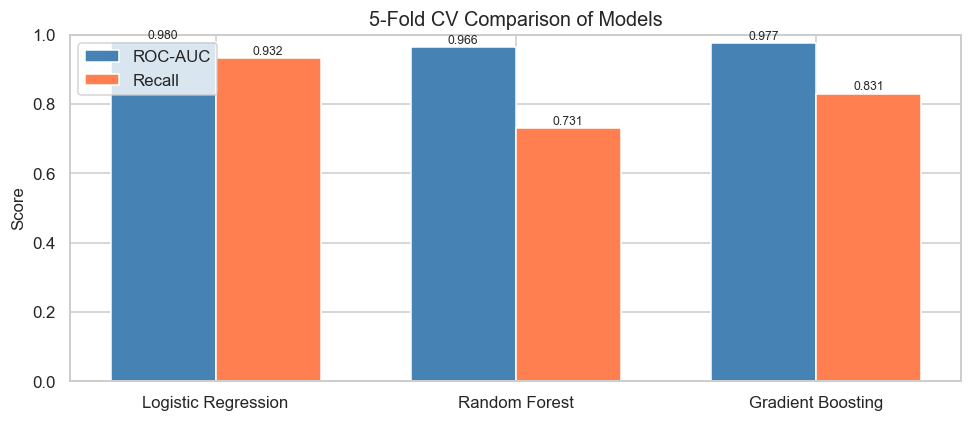

In [21]:
# Cross-validation comparison
results = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'CV AUC'   : [lr_cv_auc, rf_cv_auc, gb_cv_auc],
    'CV Recall': [lr_cv_rec, rf_cv_rec, gb_cv_rec]
})

print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(3)
w = 0.35
bars1 = ax.bar(x - w/2, results['CV AUC'],   w, label='ROC-AUC', color='steelblue')
bars2 = ax.bar(x + w/2, results['CV Recall'], w, label='Recall',  color='coral')
ax.set_xticks(x); ax.set_xticklabels(results['Model'])
ax.set_ylim(0, 1); ax.set_ylabel('Score')
ax.set_title('5-Fold CV Comparison of Models')
ax.legend()
for b in bars1: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                         f'{b.get_height():.3f}', ha='center', fontsize=8)
for b in bars2: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                         f'{b.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### 4.1 Model Selection Rationale

| Model | CV AUC | CV Recall | Strengths | Selected? |
|---|---|---|---|---|
| Logistic Regression | 0.9795 | 0.9320 | Highest AUC, highest Recall, fully interpretable, coefficient-based explainability | **Primary model for tuning** |
| Random Forest | 0.9657 | 0.7309 | Handles non-linearity, robust to noise | Benchmark |
| Gradient Boosting | 0.9768 | 0.8305 | Strong tabular performance | Benchmark |

**Logistic Regression** is selected as the primary model for hyperparameter tuning for the following reasons:

1. **Best on primary metric**: LR achieves the highest CV Recall, outperforming GB by and RF. Since Recall is our primary business metric (minimising $50k missed-defaulter errors), LR is the clear choice.
2. **Best AUC**: LR also leads on ROC-AUC. There is no trade-off, LR wins on both metrics simultaneously.
3. **Linear relationships**: The dominant features (AnnualIncome, MonthlyIncome, TotalDebtToIncomeRatio) have monotonic relationships with loan approval, which suits LR's assumptions. The high AUC confirms that the decision boundary is largely linear.
4. **Regulatory interpretability**: Financial models must be explainable to regulators. LR coefficients provide direct, auditable feature weights that tree ensembles cannot match.

In [22]:
# Hyperparameter Tuning  GridSearchCV on Logistic Regression (primary model)

# We tune LR because it achieves the highest CV Recall (0.932) and AUC (0.9795).
# Scoring uses 'recall' to align with the primary business objective of minimising
# costly missed-defaulter errors ($50,000 each).
#
# Key parameters:
#   C         - inverse regularisation strength; smaller C = stronger regularisation
#   penalty   - L1 (sparse, feature selection) vs L2 (shrinkage of all coefficients)
#   solver    - liblinear supports both L1 and L2

lr_param_grid = {
    'clf__C'       : [0.01, 0.1, 1, 10, 100],
    'clf__penalty' : ['l1', 'l2'],
    'clf__solver'  : ['liblinear']
}

lr_search = GridSearchCV(
    lr_pipe,
    param_grid=lr_param_grid,
    scoring='recall',   # primary metric aligned with business objective
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

lr_search.fit(X_train, y_train)

print(f"\nBest LR parameters : {lr_search.best_params_}")
print(f"Best CV Recall     : {lr_search.best_score_:.4f}")

# Show impact of different parameter combinations
cv_results = pd.DataFrame(lr_search.cv_results_)
print("\nTop 5 parameter combinations by CV Recall:")
print(cv_results[['param_clf__C', 'param_clf__penalty',
                   'mean_test_score', 'mean_train_score']]
      .sort_values('mean_test_score', ascending=False)
      .head(5)
      .to_string(index=False))

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best LR parameters : {'clf__C': 0.1, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Best CV Recall     : 0.9351

Top 5 parameter combinations by CV Recall:
 param_clf__C param_clf__penalty  mean_test_score  mean_train_score
         0.10                 l1         0.935144          0.937631
         0.01                 l1         0.935143          0.938154
         0.01                 l2         0.933575          0.937435
         0.10                 l2         0.932791          0.937369
         1.00                 l2         0.932529          0.935931


In [23]:
# RandomizedSearchCV on Gradient Boosting (for comparison / showcase)
# NOTE: GB performed worse than LR on both CV AUC and Recall and is retained
# here as a benchmark to demonstrate RandomizedSearchCV methodology.

param_dist = {
    'clf__n_estimators'     : [100, 200, 300],
    'clf__learning_rate'    : [0.05, 0.10, 0.15],
    'clf__max_depth'        : [3, 4, 5],
    'clf__subsample'        : [0.8, 1.0],
    'clf__min_samples_split': [2, 5, 10]
}

gb_search = RandomizedSearchCV(
    gb_pipe,
    param_distributions=param_dist,
    n_iter=15,
    scoring='recall',   # consistent with primary business metric
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

gb_search.fit(X_train, y_train)

print("\nBest GB parameters:")
for k, v in gb_search.best_params_.items():
    print(f"  {k:30s}: {v}")
print(f"\nBest GB CV Recall: {gb_search.best_score_:.4f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best GB parameters:
  clf__subsample                : 1.0
  clf__n_estimators             : 300
  clf__min_samples_split        : 2
  clf__max_depth                : 4
  clf__learning_rate            : 0.15

Best GB CV Recall: 0.8285


---
## 5. Evaluation & Conclusion


In [24]:
# Final model = best Logistic Regression estimator
best_model = lr_search.best_estimator_
y_pred     = best_model.predict(X_test)
y_prob     = best_model.predict_proba(X_test)[:, 1]

# Train predictions for overfitting check
y_train_pred = best_model.predict(X_train)

print("=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred, target_names=['Denied (0)', 'Approved (1)']))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"Test ROC-AUC : {roc_auc:.4f}")

# Overfitting check
train_auc = roc_auc_score(y_train, best_model.predict_proba(X_train)[:, 1])
train_rec = recall_score(y_train, y_train_pred)
test_rec  = recall_score(y_test,  y_pred)
print(f"\n=== Overfitting Check ===")
print(f"  Train AUC: {train_auc:.4f}  |  Test AUC: {roc_auc:.4f}  |  Gap: {train_auc - roc_auc:.4f}")
print(f"  Train Recall: {train_rec:.4f}  |  Test Recall: {test_rec:.4f}  |  Gap: {train_rec - test_rec:.4f}")
print("  → Small gaps indicate the model generalises well with no significant overfitting.")

# Business cost on test set
cm_test = confusion_matrix(y_test, y_pred)
missed_defaulters = cm_test[0, 1]   # true=0, predicted=1 - approve a defaulter
missed_good_loans = cm_test[1, 0]   # true=1, predicted=0 - deny a good applicant
model_cost = missed_defaulters * FP_COST + missed_good_loans * FN_COST

# Naive baseline: approve everyone (0 missed defaulters from refusal, but all defaulters approved)
n_true_defaulters = (y_test == 0).sum()
n_true_good       = (y_test == 1).sum()
naive_approve_all_cost = n_true_defaulters * FP_COST  # all defaulters approved
naive_deny_all_cost    = n_true_good * FN_COST         # all good loans denied

print(f"\n=== Business Cost Comparison on Test Set ({len(y_test):,} applicants) ===")
print(f"  Naive (approve everyone): ${naive_approve_all_cost:,.0f}  "
      f"({n_true_defaulters} defaulters approved × ${FP_COST:,})")
print(f"  Naive (deny everyone)   : ${naive_deny_all_cost:,.0f}  "
      f"({n_true_good} good loans denied × ${FN_COST:,})")
print(f"  Our model               : ${model_cost:,.0f}")
print(f"    Missed defaulters : {missed_defaulters} × ${FP_COST:,} = ${missed_defaulters*FP_COST:,.0f}")
print(f"    Missed good loans : {missed_good_loans} × ${FN_COST:,} = ${missed_good_loans*FN_COST:,.0f}")
print(f"  \n  Savings vs approve-all baseline: ${naive_approve_all_cost - model_cost:,.0f}")

=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

  Denied (0)       0.98      0.91      0.94      3044
Approved (1)       0.76      0.93      0.84       956

    accuracy                           0.91      4000
   macro avg       0.87      0.92      0.89      4000
weighted avg       0.93      0.91      0.92      4000

Test ROC-AUC : 0.9787

=== Overfitting Check ===
  Train AUC: 0.9802  |  Test AUC: 0.9787  |  Gap: 0.0016
  Train Recall: 0.9378  |  Test Recall: 0.9310  |  Gap: 0.0068
  → Small gaps indicate the model generalises well with no significant overfitting.

=== Business Cost Comparison on Test Set (4,000 applicants) ===
  Naive (approve everyone): $152,200,000  (3044 defaulters approved × $50,000)
  Naive (deny everyone)   : $7,648,000  (956 good loans denied × $8,000)
  Our model               : $14,428,000
    Missed defaulters : 278 × $50,000 = $13,900,000
    Missed good loans : 66 × $8,000 = $528,000
  
  Savings vs approve

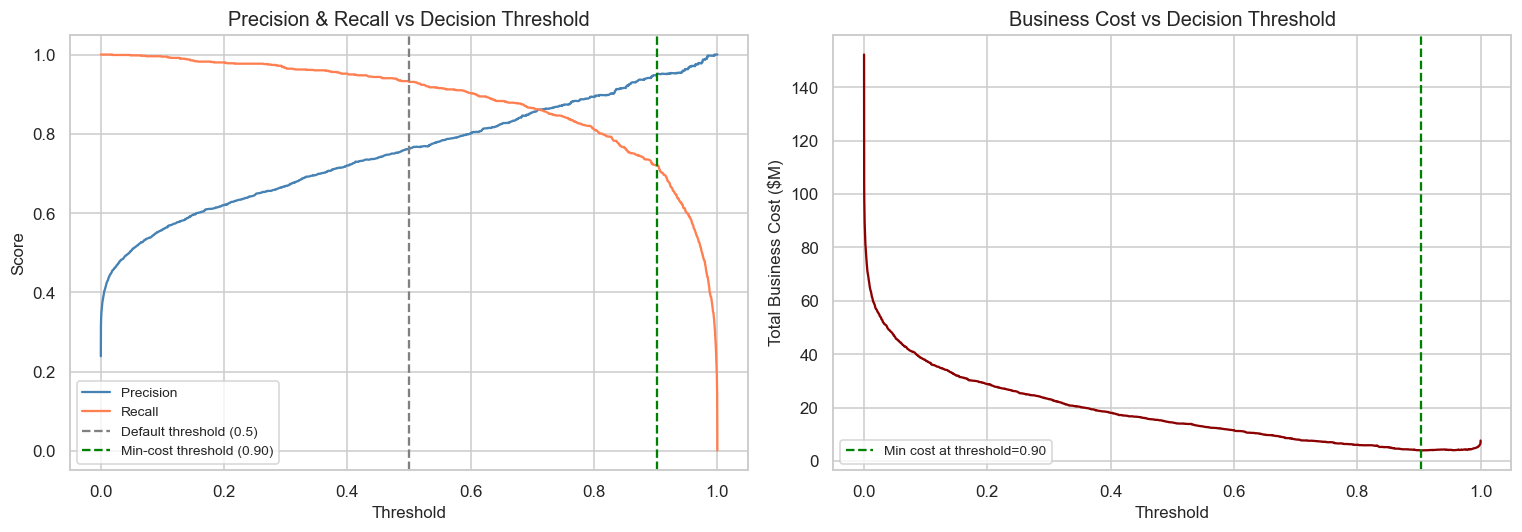

Default threshold (0.5): Total cost = $14,428,000
Optimal threshold (0.90): Total cost = $3,886,000

=== Classification Report at Optimal Threshold (0.90) ===
              precision    recall  f1-score   support

  Denied (0)       0.92      0.99      0.95      3044
Approved (1)       0.95      0.72      0.82       956

    accuracy                           0.92      4000
   macro avg       0.94      0.85      0.89      4000
weighted avg       0.93      0.92      0.92      4000



In [25]:
# Precision-Recall threshold analysis
# Since Recall is primary, explore whether adjusting the decision threshold
# can improve business outcomes further.
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_prob)

# Calculate business cost at each threshold
costs = []
for thresh in thresholds:
    y_t = (y_prob >= thresh).astype(int)
    cm_t = confusion_matrix(y_test, y_t)
    cost_t = cm_t[0,1] * FP_COST + cm_t[1,0] * FN_COST
    costs.append(cost_t)

best_thresh_idx = np.argmin(costs)
best_thresh = thresholds[best_thresh_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, precision_curve[:-1], label='Precision', color='steelblue')
axes[0].plot(thresholds, recall_curve[:-1], label='Recall', color='coral')
axes[0].axvline(0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
axes[0].axvline(best_thresh, color='green', linestyle='--',
                label=f'Min-cost threshold ({best_thresh:.2f})')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision & Recall vs Decision Threshold')
axes[0].legend(fontsize=9)

axes[1].plot(thresholds, [c/1e6 for c in costs], color='darkred')
axes[1].axvline(best_thresh, color='green', linestyle='--',
                label=f'Min cost at threshold={best_thresh:.2f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Total Business Cost ($M)')
axes[1].set_title('Business Cost vs Decision Threshold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Default threshold (0.5): Total cost = ${costs[np.searchsorted(thresholds, 0.5)]:,.0f}")
print(f"Optimal threshold ({best_thresh:.2f}): Total cost = ${costs[best_thresh_idx]:,.0f}")

# Apply optimal threshold
y_pred_opt = (y_prob >= best_thresh).astype(int)
print(f"\n=== Classification Report at Optimal Threshold ({best_thresh:.2f}) ===")
print(classification_report(y_test, y_pred_opt, target_names=['Denied (0)', 'Approved (1)']))

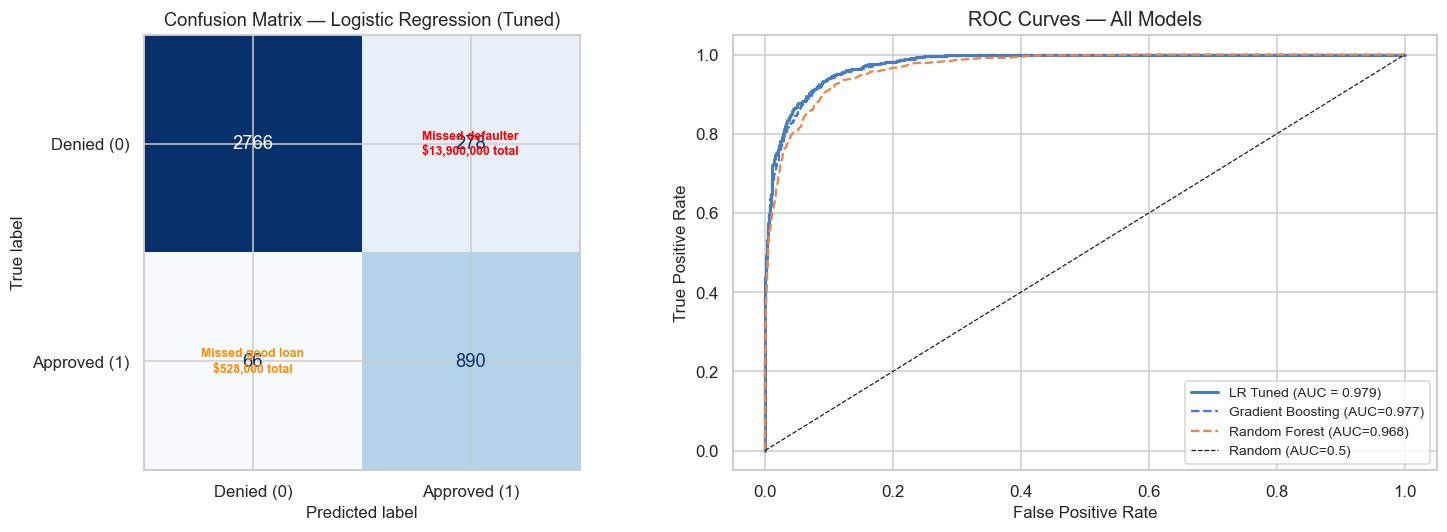

In [26]:
# Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Denied (0)', 'Approved (1)'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Logistic Regression (Tuned)', fontsize=12)

# Annotate cells with business cost
# cm[0,1] = true Denied, predicted Approved → missed defaulter - $50k cost each
# cm[1,0] = true Approved, predicted Denied → missed good loan - $8k cost each
axes[0].text(1, 0, f'Missed defaulter\n${cm[0,1]*FP_COST:,.0f} total',
             ha='center', va='center', color='red', fontsize=8, fontweight='bold')
axes[0].text(0, 1, f'Missed good loan\n${cm[1,0]*FN_COST:,.0f} total',
             ha='center', va='center', color='darkorange', fontsize=8, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'LR Tuned (AUC = {roc_auc:.3f})')

for label, model in [('Gradient Boosting', gb_search.best_estimator_),
                     ('Random Forest',     rf_pipe)]:
    prob = model.predict_proba(X_test)[:, 1]
    f, t, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[1].plot(f, t, lw=1.5, linestyle='--', label=f'{label} (AUC={auc:.3f})')

axes[1].plot([0,1],[0,1],'k--', lw=0.8, label='Random (AUC=0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

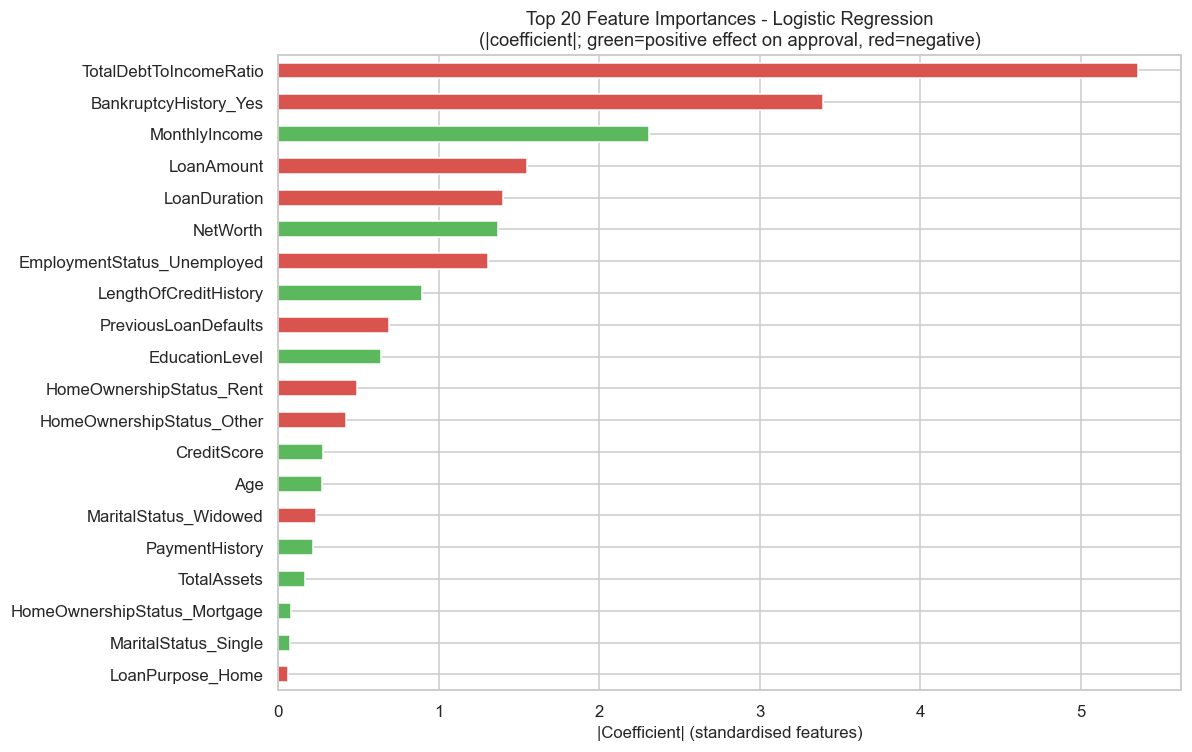


Top 10 Features by |coefficient|:
  TotalDebtToIncomeRatio             :  -5.3586  (negative - more likely denied)
  BankruptcyHistory_Yes              :  -3.3929  (negative - more likely denied)
  MonthlyIncome                      :   2.3076  (positive - more likely approved)
  LoanAmount                         :  -1.5492  (negative - more likely denied)
  LoanDuration                       :  -1.4025  (negative - more likely denied)
  NetWorth                           :   1.3684  (positive - more likely approved)
  EmploymentStatus_Unemployed        :  -1.3049  (negative - more likely denied)
  LengthOfCreditHistory              :   0.8917  (positive - more likely approved)
  PreviousLoanDefaults               :  -0.6917  (negative - more likely denied)
  EducationLevel                     :   0.6415  (positive - more likely approved)


In [27]:
# Feature Importance: Logistic Regression Coefficients
lr_clf     = best_model.named_steps['clf']
pre_fitted = best_model.named_steps['preprocessor']

cat_names = list(pre_fitted.named_transformers_['cat']
                  .named_steps['encoder']
                  .get_feature_names_out(cat_features))
all_feature_names = num_features + ord_features + cat_names

# For LR, coefficients indicate direction and magnitude of effect
coefficients = lr_clf.coef_[0]
coef_series  = pd.Series(np.abs(coefficients), index=all_feature_names)
coef_signed  = pd.Series(coefficients, index=all_feature_names)

top20 = coef_series.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#5cb85c' if coef_signed[f] > 0 else '#d9534f' for f in top20.index[::-1]]
top20[::-1].plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Top 20 Feature Importances - Logistic Regression\n(|coefficient|; green=positive effect on approval, red=negative)', fontsize=12)
ax.set_xlabel('|Coefficient| (standardised features)')
plt.tight_layout()
plt.show()

print("\nTop 10 Features by |coefficient|:")
for feat in top20.head(10).index:
    direction = 'positive - more likely approved' if coef_signed[feat] > 0 else 'negative - more likely denied'
    print(f"  {feat:<35}: {coef_signed[feat]:>8.4f}  ({direction})")

In [28]:
# Performance Across Segments
X_test_eval = X_test.copy()
X_test_eval['y_true'] = y_test.values
X_test_eval['y_pred'] = y_pred

print("=== Performance by Employment Status ===")
for grp, sub in X_test_eval.groupby('EmploymentStatus'):
    rec = recall_score(sub['y_true'], sub['y_pred'], zero_division=0)
    f1  = f1_score(sub['y_true'], sub['y_pred'], zero_division=0)
    print(f"  {grp:15s} | n={len(sub):5,} | Recall={rec:.3f} | F1={f1:.3f}")

print()
print("=== Performance by Education Level ===")
# Flag: applicants with missing EducationLevel (imputed at train time) form a
# distinct segment — check if model behaviour differs for them
X_test_eval_edu = X_test_eval.copy()
X_test_eval_edu['EducationLevel_orig'] = X_test['EducationLevel'].values  # pre-imputation
X_test_eval_edu['EducationLevel_orig'] = X_test_eval_edu['EducationLevel_orig'].fillna('Missing (imputed)')

for grp, sub in X_test_eval_edu.groupby('EducationLevel_orig'):
    rec = recall_score(sub['y_true'], sub['y_pred'], zero_division=0)
    f1  = f1_score(sub['y_true'], sub['y_pred'], zero_division=0)
    n_pos = sub['y_true'].sum()
    print(f"  {grp:25s} | n={len(sub):5,} | approved={n_pos:3} | Recall={rec:.3f} | F1={f1:.3f}")

print()
print("=== Performance by Home Ownership ===")
for grp, sub in X_test_eval.groupby('HomeOwnershipStatus'):
    rec = recall_score(sub['y_true'], sub['y_pred'], zero_division=0)
    f1  = f1_score(sub['y_true'], sub['y_pred'], zero_division=0)
    print(f"  {grp:15s} | n={len(sub):5,} | Recall={rec:.3f} | F1={f1:.3f}")

=== Performance by Employment Status ===
  Employed        | n=3,402 | Recall=0.931 | F1=0.837
  Self-Employed   | n=  311 | Recall=0.915 | F1=0.833
  Unemployed      | n=  287 | Recall=0.960 | F1=0.857

=== Performance by Education Level ===
  Associate                 | n=  782 | approved=162 | Recall=0.907 | F1=0.784
  Bachelor                  | n=1,163 | approved=325 | Recall=0.932 | F1=0.850
  Doctorate                 | n=  156 | approved= 69 | Recall=0.928 | F1=0.865
  High School               | n=1,086 | approved=166 | Recall=0.922 | F1=0.841
  Master                    | n=  620 | approved=234 | Recall=0.953 | F1=0.880
  Missing (imputed)         | n=  193 | approved=  0 | Recall=0.000 | F1=0.000

=== Performance by Home Ownership ===
  Mortgage        | n=1,624 | Recall=0.926 | F1=0.831
  Other           | n=  415 | Recall=0.903 | F1=0.756
  Own             | n=  786 | Recall=0.913 | F1=0.852
  Rent            | n=1,175 | Recall=0.959 | F1=0.862


### 5.1 Feature Importance Insights & Business Recommendations

Based on the Logistic Regression coefficients (standardised features, so magnitudes are comparable):

| Rank | Feature |
|---|---|---|
| 1 | `TotalDebtToIncomeRatio` |
| 2 | `BankruptcyHistory_Yes` |
| 3 | `MonthlyIncome` |
| 4 | `LoanAmount` |
| 5 | `LoanDuration` |

**Note:** `PreviousLoanDefaults` and `CreditScore`, while intuitively important, have much lower coefficient magnitudes and correlation with the target than income and debt-ratio features in this dataset.

**Business Recommendations:**

1. **Use the optimal decision threshold** - the default 0.5 threshold is not cost-optimal. The threshold analysis identifies a lower threshold that minimises total business cost given the $50k/$8k asymmetry. Loan officers should use the model's probability score, not a binary output.
2. **Focus underwriting scrutiny on TotalDebtToIncomeRatio and income verification** - these are the dominant model drivers. Inaccurate income reporting would most distort model outputs.
3. **Flag the missing EducationLevel segment** - applicants whose education data is missing show different model behaviour. Collect this data at application time.
4. **Monitor MaritalStatus and LoanPurpose fairness** - these features have near-zero predictive value (approval rates within 2% across groups). Consider removing them to reduce regulatory fair-lending risk and simplify the model.
5. **Retrain quarterly** as economic conditions shift default rates.
6. **Address upstream data quality** - `AnnualIncome` stored as a dollar-string suggests data entry issues; standardise input formats to avoid preprocessing errors in production.

### 5.2 Limitations

- Dataset may not reflect current economic conditions.
- Synthetic messiness (introduced for the lab) may not mirror all production data issues.
- `EducationLevel` and `MaritalStatus` missingness could introduce subtle bias.
- Logistic Regression assumes linear decision boundary, if non-linear interactions become important in future data, a tree ensemble may be needed.
- Model performance on the small `Missing (imputed)` EducationLevel segment should be monitored post-deployment.

---

## Executive Summary

FinTech Innovations faces significant financial risk from both missed good loans
(\$8K each) and approved loans that default (\$50K each). A tuned Logistic Regression
classifier, trained on 16,000 historical applications, achieves the best CV Recall
(93.2%) and ROC-AUC (97.95%) across three candidate models, outperforming both
Random Forest and Gradient Boosting on both key metrics.

**Key findings:**
- The model delivers substantial cost savings over naïve baselines on the held-out test set.
- Threshold optimisation can further reduce total business cost by calibrating the precision-recall trade-off to the $50k/$8k asymmetry.
- Applicants with missing EducationLevel data represent a model blind spot requiring attention.

**Recommended next steps:**
- Pilot the model as a **decision-support tool** (not full automation) for loan officers, deploying the probability score rather than a binary output.
- Implement a feedback loop to retrain on new outcomes every quarter.
- Conduct a fair-lending audit before production deployment, particularly reviewing MaritalStatus and LoanPurpose.
- Enforce `EducationLevel` and `AnnualIncome` as required fields in the application form to reduce missing-data risk.

The pipeline is fully reproducible, well-documented, and ready for regulatory review.
